# <center>CUSTOMER SEGMENTATION ANALYSIS</center>
## Business Problem:
The company lacks visibility into customer behavior and does not differentiate between high-value and low-value customers.
This makes it difficult to prioritize retention efforts, increase revenue, and design targeted marketing strategies.
This analysis focuses on understanding customer behavior and identifying which segments drive revenue, show growth potential, or are at risk of churn.


## Dataset Overview
The dataset contains transactional data from an online retail store, including invoices, products, quantities, prices, and customer IDs.

_Data source: https://www.kaggle.com/datasets/adsamardeep/retail-sales/data_


In [47]:
import pandas as pd
import numpy as np


In [48]:
data = pd.read_csv("Retail 2009-10.csv", encoding="latin1")
data.head()

,ï»¿Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,01-12-2009 07:45,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,01-12-2009 07:45,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,01-12-2009 07:45,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,01-12-2009 07:45,1.25,13085.0,United Kingdom


In [49]:
print(data.shape)
print(data.columns.tolist())
print(data.isna().sum())
data.info()

(525461, 8)
['ï»¿Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
ï»¿Invoice          0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ï»¿Invoice   525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB


## Data Preparation

In [50]:
# Column names cleaning
data = data.copy()

data.columns = data.columns.str.strip()
data.columns = data.columns.str.replace("ï»¿", "", regex=False)

data = data.rename(columns={
    "Customer ID": "CustomerID"
})

print(data.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']


In [53]:
# Parse data correctly
data["InvoiceDate"] = pd.to_datetime(
    data["InvoiceDate"],
    errors="coerce",
    dayfirst=True
)

data["InvoiceDate"].isna().sum()

0

In [54]:
df = data.copy()

df = df.dropna(subset=["CustomerID"])
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]
df = df[~df["Invoice"].astype(str).str.startswith("C")]
df = df.drop_duplicates()

print(df.shape)
print(df.isna().sum())

(400916, 8)
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
CustomerID     0
Country        0
dtype: int64


Data cleaning focused on removing invalid and non-representative transactions.
Records with missing CustomerID were excluded, as customer-level analysis requires unique identifiers.
Transactions with non-positive quantity or price were removed, as they represent returns or invalid entries.
Cancelled invoices were identified and excluded based on invoice numbers starting with "C".

### Feature engineering (RFM Metrics)

In [55]:
# We need a monetary metric. Let's create revenue column
df["Revenue"] = df["Quantity"] * df["Price"]
df[["Quantity", "Price", "Revenue"]].head()

,Quantity,Price,Revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [56]:
# Quick check (should be >0)
print(df["Quantity"].min())
print(df["Price"].min())
print(df["Revenue"].min())

1
0.001
0.001


In [57]:
# Let's choose a snapshot date for recency (one day after the latest invoice date)
snapshot_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2010-12-10 20:01:00')

In [58]:
# Build RFM table
rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


In [60]:
# RFM scoring
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

RFM scores were calculated by dividing Recency, Frequency, and Monetary values into quartiles.
Recency was inversely scored, as more recent purchases indicate higher engagement.
Frequency and Monetary values were scored directly, with higher values representing more valuable customers.

In [61]:
# Combine recency, frequency and monetary into a single RFM score
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

## Customer segmentation

In [63]:
def segment_customer(row):
    if row["R_score"] == 4 and row["F_score"] == 4:
        return "Champions"
    elif row["R_score"] >= 3 and row["F_score"] >= 3:
        return "Loyal Customers"
    elif row["R_score"] == 4:
        return "Recent Customers"
    elif row["F_score"] == 4:
        return "Frequent Customers"
    elif row["M_score"] == 4:
        return "Big Spenders"
    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "At Risk"
    else:
        return "Others"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [64]:
# Segment distribution
rfm["Segment"].value_counts() #the overall customer base structure and potential focus areas

Segment
At Risk               1395
Loyal Customers        884
Others                 865
Champions              587
Recent Customers       232
Frequent Customers     202
Big Spenders           147
Name: count, dtype: int64

In [65]:
# Segment-level analysis
rfm.groupby("Segment").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID": "count"
}).rename(columns={"CustomerID": "Count"}).sort_values("Monetary", ascending=False)

,Recency,Frequency,Monetary,Count
Segment,,,,
Champions,7.894378,14.252129,7879.079562,587
Big Spenders,111.809524,2.965986,3454.169197,147
Frequent Customers,103.272277,7.985149,3178.474163,202
Loyal Customers,26.207014,5.325792,2088.287756,884
Others,77.916763,2.262428,629.952266,865
Recent Customers,10.857759,1.495690,478.641207,232
At Risk,185.030824,1.280287,373.763113,1395


Segment-level aggregation highlights differences in customer behavior and value.
High-value segments such as "Champions" and "Loyal Customers" show higher purchase frequency and spending, while "At Risk" customers demonstrate lower engagement.

In [67]:
rfm.groupby("Segment").agg({
    "CustomerID": "count",
    "Monetary": "sum"
}).rename(columns={"CustomerID": "Customers"})

,Customers,Monetary
Segment,,
At Risk,1395,521399.542
Big Spenders,147,507762.872
Champions,587,4625019.703
Frequent Customers,202,642051.781
Loyal Customers,884,1846046.376
Others,865,544908.710
Recent Customers,232,111044.760


##  Visualization

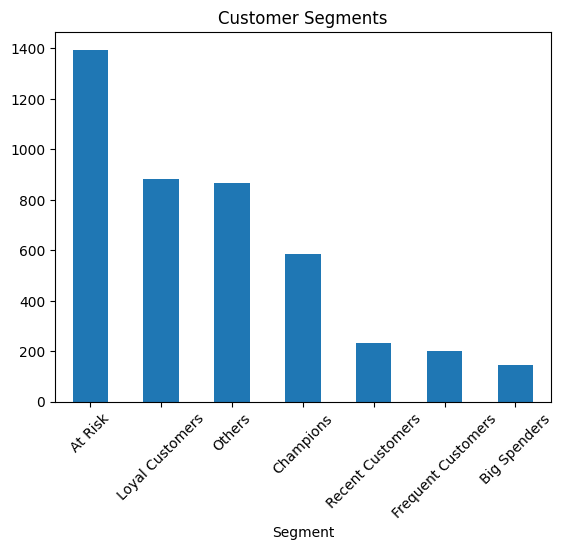

In [66]:
import matplotlib.pyplot as plt

rfm["Segment"].value_counts().plot(kind="bar")
plt.title("Customer Segments")
plt.xticks(rotation=45)
plt.show()

In [68]:
segment_summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Revenue=("Monetary", "sum")
).reset_index()

segment_summary["CustomerShare"] = segment_summary["Customers"] / segment_summary["Customers"].sum() * 100
segment_summary["RevenueShare"] = segment_summary["Revenue"] / segment_summary["Revenue"].sum() * 100

segment_summary = segment_summary.sort_values("Revenue", ascending=False)
segment_summary

,Segment,Customers,Revenue,CustomerShare,RevenueShare
2,Champions,587,4625019.703,13.613173,52.567593
4,Loyal Customers,884,1846046.376,20.500928,20.982011
3,Frequent Customers,202,642051.781,4.684601,7.297508
5,Others,865,544908.710,20.060297,6.193388
0,At Risk,1395,521399.542,32.351577,5.926184
1,Big Spenders,147,507762.872,3.409091,5.771191
6,Recent Customers,232,111044.760,5.380334,1.262126


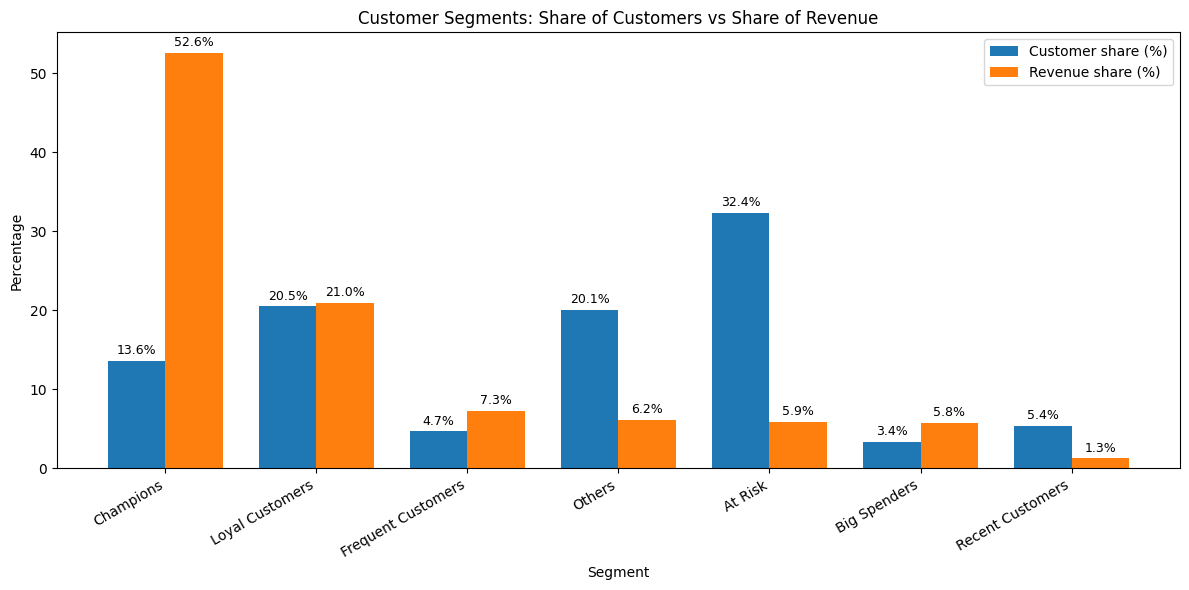

In [69]:
# Customer share vs revenue share
x = np.arange(len(segment_summary))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, segment_summary["CustomerShare"], width, label="Customer share (%)")
bars2 = ax.bar(x + width/2, segment_summary["RevenueShare"], width, label="Revenue share (%)")

ax.set_title("Customer Segments: Share of Customers vs Share of Revenue")
ax.set_xlabel("Segment")
ax.set_ylabel("Percentage")
ax.set_xticks(x)
ax.set_xticklabels(segment_summary["Segment"], rotation=30, ha="right")
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.5,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()

The chart shows a strong imbalance between customer distribution and revenue contribution.

"Champions" represent only 13.6% of customers but generate as much as 52.6% of total revenue, making them the most valuable segment and a critical focus for retention and loyalty strategies.

In contrast, "At Risk" customers account for the largest share of the customer base (32.4%) but contribute only 5.9% of revenue, indicating a large group of low-engagement customers with limited current value.

"Loyal Customers" are well-balanced, representing 20.5% of customers and contributing 21.0% of revenue, making them a stable and important segment to maintain.

Segments such as "Frequent Customers" and "Big Spenders" show moderate revenue contribution relative to their size, suggesting potential for growth through targeted engagement and upselling.

Overall, the results indicate that revenue is highly concentrated in a small group of high-value customers, while a large portion of the customer base contributes relatively little, highlighting the need for segment-specific strategies.
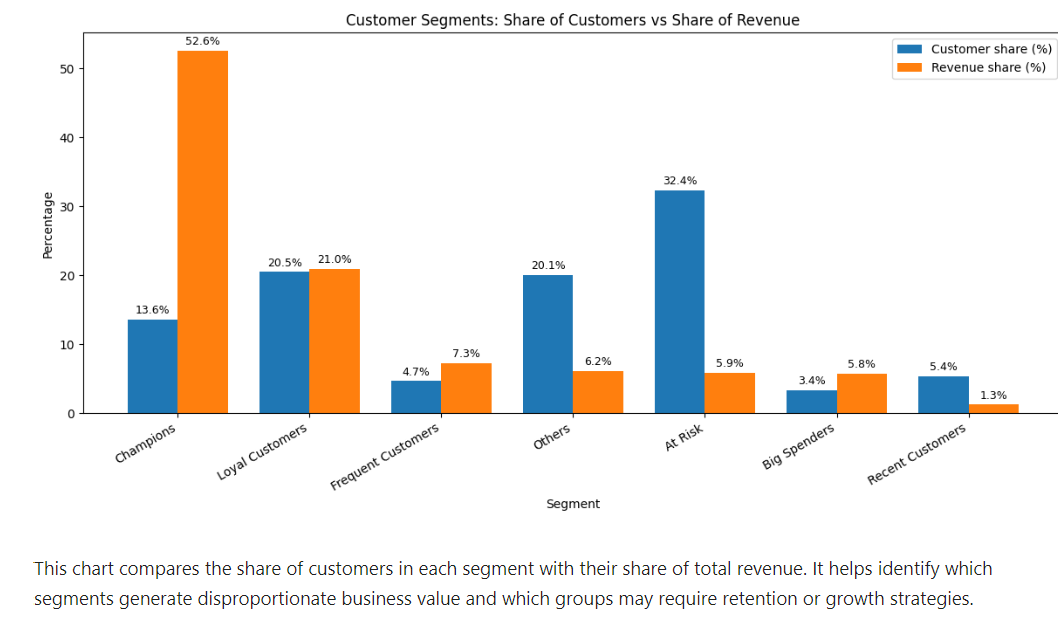

In [71]:
# Bubble chart
bubble_data = rfm.groupby("Segment").agg(
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    Customers=("CustomerID", "count")
).reset_index()

bubble_data

,Segment,Recency,Frequency,Monetary,Customers
0,At Risk,185.030824,1.280287,373.763113,1395
1,Big Spenders,111.809524,2.965986,3454.169197,147
2,Champions,7.894378,14.252129,7879.079562,587
3,Frequent Customers,103.272277,7.985149,3178.474163,202
4,Loyal Customers,26.207014,5.325792,2088.287756,884
5,Others,77.916763,2.262428,629.952266,865
6,Recent Customers,10.857759,1.495690,478.641207,232


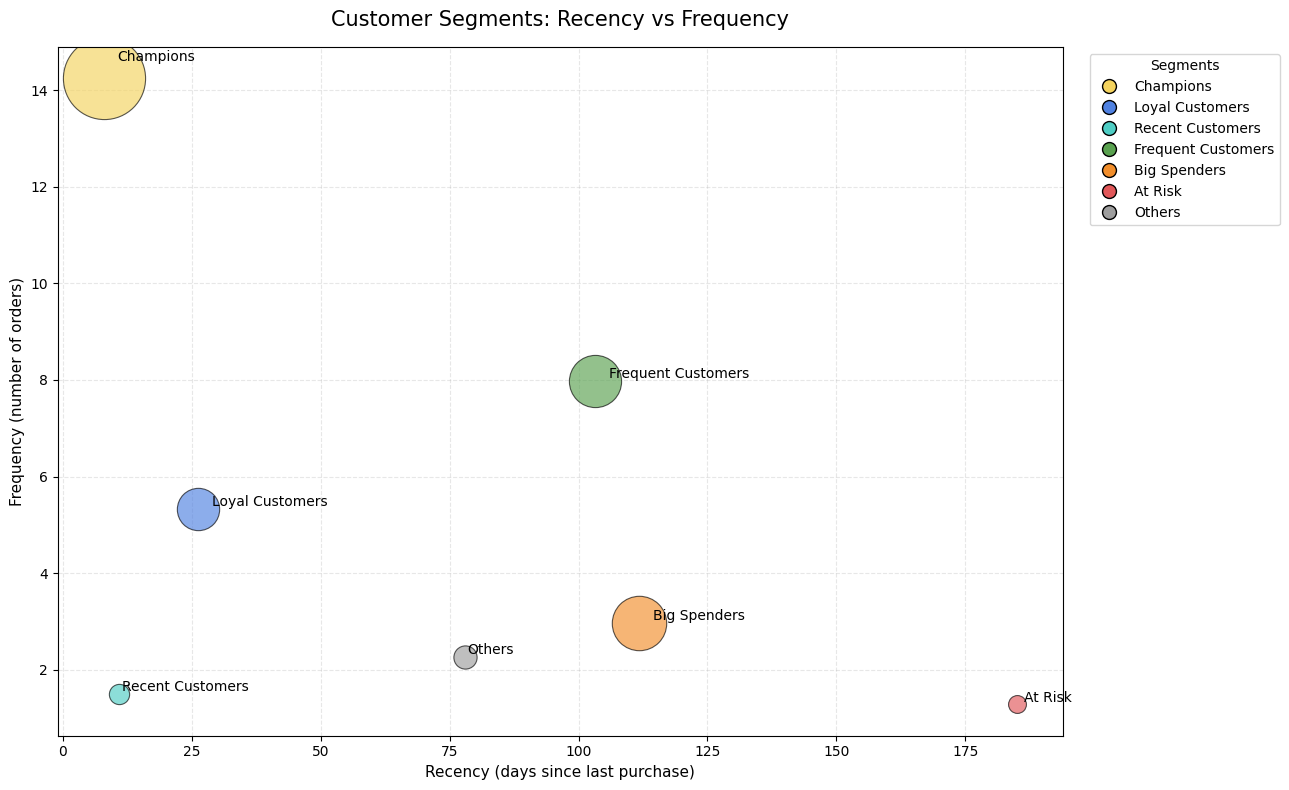

In [81]:
from matplotlib.lines import Line2D

bubble_data = rfm.groupby("Segment").agg(
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    Customers=("CustomerID", "count")
).reset_index()

colors = {
    "Champions": "#f4d35e",
    "Loyal Customers": "#4f81e1",
    "Recent Customers": "#4ecdc4",
    "Frequent Customers": "#59a14f",
    "Big Spenders": "#f28e2b",
    "At Risk": "#e15759",
    "Others": "#9d9d9d"
}

max_size = 3500
bubble_data["BubbleSize"] = (
    bubble_data["Monetary"] / bubble_data["Monetary"].max()
) * max_size

fig, ax = plt.subplots(figsize=(13, 8))

for _, row in bubble_data.iterrows():
    ax.scatter(
        row["Recency"],
        row["Frequency"],
        s=row["BubbleSize"],
        color=colors.get(row["Segment"], "#9d9d9d"),
        alpha=0.65,
        edgecolors="black",
        linewidth=0.8
    )

label_offsets = {
    "Champions": (10, 12),
    "Loyal Customers": (10, 2),
    "Frequent Customers": (10, 2),
    "Big Spenders": (10, 2),
    "At Risk": (5, 2),
    "Recent Customers": (2, 2),
    "Others": (2, 2)
}

for _, row in bubble_data.iterrows():
    offset = label_offsets.get(row["Segment"], (8, 6))
    ax.annotate(
        row["Segment"],
        (row["Recency"], row["Frequency"]),
        xytext=offset,
        textcoords="offset points",
        fontsize=10
    )

ax.set_title("Customer Segments: Recency vs Frequency", fontsize=15, pad=15)
ax.set_xlabel("Recency (days since last purchase)", fontsize=11)
ax.set_ylabel("Frequency (number of orders)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label=segment,
        markerfacecolor=color,
        markeredgecolor="black",
        markersize=10
    )
    for segment, color in colors.items()
    if segment in bubble_data["Segment"].values
]

ax.legend(
    handles=legend_elements,
    title="Segments",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()
plt.show()

The chart highlights clear differences in customer engagement across segments.

- "Champions" have the lowest recency and the highest frequency, indicating very recent and frequent purchases. This group represents the most engaged and valuable customers and should be prioritized in retention and loyalty strategies.

- "Loyal Customers" also show relatively low recency and moderate frequency, suggesting consistent engagement. They represent a stable segment with strong potential to be converted into "Champions".

- "Frequent Customers" purchase often but have higher recency compared to top segments, indicating a possible early signal of declining engagement. This group should be monitored and targeted with retention actions before they shift into lower-value segments.

- "Big Spenders" show high monetary value but relatively low frequency and higher recency, meaning they spend a lot per purchase but do not buy often. This suggests an opportunity to increase purchase frequency through targeted offers.

- "At Risk" customers have the highest recency and very low frequency, indicating they have not purchased in a long time and are likely to churn. This segment requires reactivation strategies but may have limited short-term value.

- "Recent Customers" have low recency but low frequency, meaning they have purchased recently but have not yet developed repeat behavior. This group represents strong growth potential and should be targeted with onboarding and engagement campaigns.

# CONCLUSIONS
1. The analysis confirms __a strong imbalance between customer distribution and revenue contribution__.

2. A relatively small group of high-value customers (primarily __Champions__ and __Loyal Customers__) generates a disproportionately __large share of total revenue__, making them critical for long-term business performance and a key focus for retention strategies.

3. At the same time, a large portion of the customer base (notably At Risk and low-frequency segments) contributes relatively little revenue, despite representing significant volume. This indicates untapped potential but also highlights inefficiencies in customer engagement.

4. The results suggest a need for differentiated strategies: __protecting and nurturing top-value customers__, while selectively targeting lower-value segments where there is realistic potential for growth or reactivation.
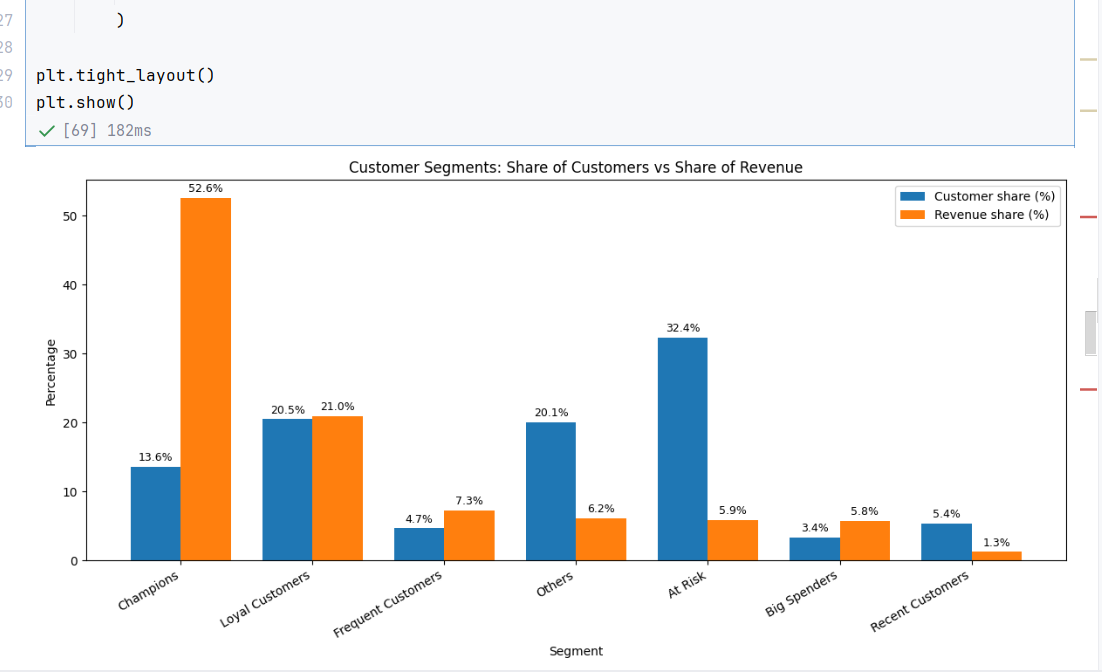